In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import os

Define Data & other Paths

In [162]:
originalDataPath = '../OriginalData/c10-decoded'
preprocessedDataPath = '../PreprocessedData/'
reportPath = '../MyWorkReports/'

Create output directories if they don't exist for work

In [163]:
os.makedirs(preprocessedDataPath, exist_ok=True)
os.makedirs(reportPath, exist_ok=True)

Loading the Raw data

In [164]:
col_names = ['az', 'gx', 'gy', 'gz', 'ax', 'ay']
df0 = pd.read_csv(originalDataPath, sep='\t', names=col_names,index_col=False)

In [165]:
df0.head()

,az,gx,gy,gz,ax,ay
0,"2,19","325,08","15,54","-1,54","0,16","-0,48"
1,"2,10","325,78","15,40","-1,96","0,13","-0,37"
2,"2,25","328,02","15,40","-2,66","-0,00","-0,30"
3,"2,62","329,70","15,54","-3,36","-0,24","-0,23"
4,"2,85","331,24","16,52","-3,50","-0,47","-0,11"


Notes : in the data set changed "," into "." - In the original data set got numerical values includin "," - Changed them to prevent the errors and to get the best results.

In [166]:
col_names = ['az', 'gx', 'gy', 'gz', 'ax', 'ay']
df = pd.read_csv(originalDataPath, sep='\t', names=col_names, decimal=',', index_col=False)

In [167]:
df.head()

,az,gx,gy,gz,ax,ay
0,2.19,325.08,15.54,-1.54,0.16,-0.48
1,2.10,325.78,15.40,-1.96,0.13,-0.37
2,2.25,328.02,15.40,-2.66,-0.00,-0.30
3,2.62,329.70,15.54,-3.36,-0.24,-0.23
4,2.85,331.24,16.52,-3.50,-0.47,-0.11


Unit convert

In [168]:
df['gx_rad'] = np.deg2rad(df['gx'])

In [169]:
df.head()

,az,gx,gy,gz,ax,ay,gx_rad
0,2.19,325.08,15.54,-1.54,0.16,-0.48,5.673716
1,2.10,325.78,15.40,-1.96,0.13,-0.37,5.685934
2,2.25,328.02,15.40,-2.66,-0.00,-0.30,5.725029
3,2.62,329.70,15.54,-3.36,-0.24,-0.23,5.754351
4,2.85,331.24,16.52,-3.50,-0.47,-0.11,5.781229


Changing the Time Vector
Sampling rate = 833 Hz.

In [170]:
fs = 833.0
dt = 1.0 / fs
df['time'] = df.index * dt

In [171]:
df.head()

,az,gx,gy,gz,ax,ay,gx_rad,time
0,2.19,325.08,15.54,-1.54,0.16,-0.48,5.673716,0.000000
1,2.10,325.78,15.40,-1.96,0.13,-0.37,5.685934,0.001200
2,2.25,328.02,15.40,-2.66,-0.00,-0.30,5.725029,0.002401
3,2.62,329.70,15.54,-3.36,-0.24,-0.23,5.754351,0.003601
4,2.85,331.24,16.52,-3.50,-0.47,-0.11,5.781229,0.004802


In [172]:
print(f"Data Loaded. Total Samples: {len(df)}")
print(f"Duration: {df['time'].iloc[-1]:.2f} seconds")
df.head()

Data Loaded. Total Samples: 35307
Duration: 42.38 seconds


,az,gx,gy,gz,ax,ay,gx_rad,time
0,2.19,325.08,15.54,-1.54,0.16,-0.48,5.673716,0.000000
1,2.10,325.78,15.40,-1.96,0.13,-0.37,5.685934,0.001200
2,2.25,328.02,15.40,-2.66,-0.00,-0.30,5.725029,0.002401
3,2.62,329.70,15.54,-3.36,-0.24,-0.23,5.754351,0.003601
4,2.85,331.24,16.52,-3.50,-0.47,-0.11,5.781229,0.004802


Null check

In [173]:
null_counts = df.isnull().sum()
print(null_counts)

az        0
gx        0
gy        0
gz        0
ax        0
ay        0
gx_rad    0
time      0
dtype: int64


Duplicate Check - Full ROW wise

In [174]:
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicate_count}")

Total Duplicate Rows: 0


Saving the Preprocessed data

In [175]:
preData = preprocessedDataPath + 'PreprocessedTireData.csv'

In [176]:
df.to_csv(clean_file_path, index=False)
print(f"Cleaned data saved to: {preData}")

Cleaned data saved to: ../PreprocessedData/PreprocessedTireData.csv


Loading the Preprocessed work for the next steps

In [177]:
df = pd.read_csv(preData)
df.head()

,az,gx,gy,gz,ax,ay,gx_rad,time
0,2.19,325.08,15.54,-1.54,0.16,-0.48,5.673716,0.000000
1,2.10,325.78,15.40,-1.96,0.13,-0.37,5.685934,0.001200
2,2.25,328.02,15.40,-2.66,-0.00,-0.30,5.725029,0.002401
3,2.62,329.70,15.54,-3.36,-0.24,-0.23,5.754351,0.003601
4,2.85,331.24,16.52,-3.50,-0.47,-0.11,5.781229,0.004802


Getting the Plots

In [178]:
plt.figure(figsize=(15, 8))

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

Subplot 1: Radial Acceleration (The "Well")

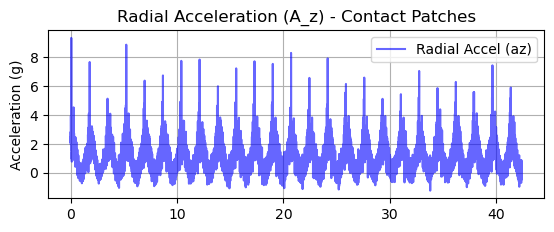

In [179]:
plt.subplot(2, 1, 1)
plt.plot(df['time'], df['az'], label='Radial Accel (az)', color='blue', alpha=0.6)
plt.title("Radial Acceleration (A_z) - Contact Patches")
plt.ylabel("Acceleration (g)")
plt.grid(True)
plt.legend()

Subplot 2: Angular Velocity (The Speed)

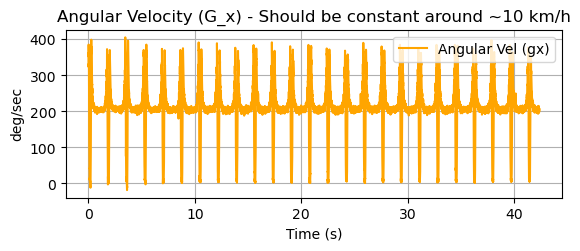

In [180]:
plt.subplot(2, 1, 2)
plt.plot(df['time'], df['gx'], label='Angular Vel (gx)', color='orange')
plt.title("Angular Velocity (G_x) - Should be constant around ~10 km/h")
plt.ylabel("deg/sec")
plt.xlabel("Time (s)")
plt.grid(True)
plt.legend()

Note : removing the vibration (jitter) caused by the rough road surface so we can see the clear shape of the tire deformation, and do the next steps more efectively.

In [181]:
def low_pass_filter(data, cutoff, fs, order=4):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, data)

In [182]:
df['az_filt'] = low_pass_filter(df['az'], cutoff=50, fs=fs)

Compare Raw vs Filtered

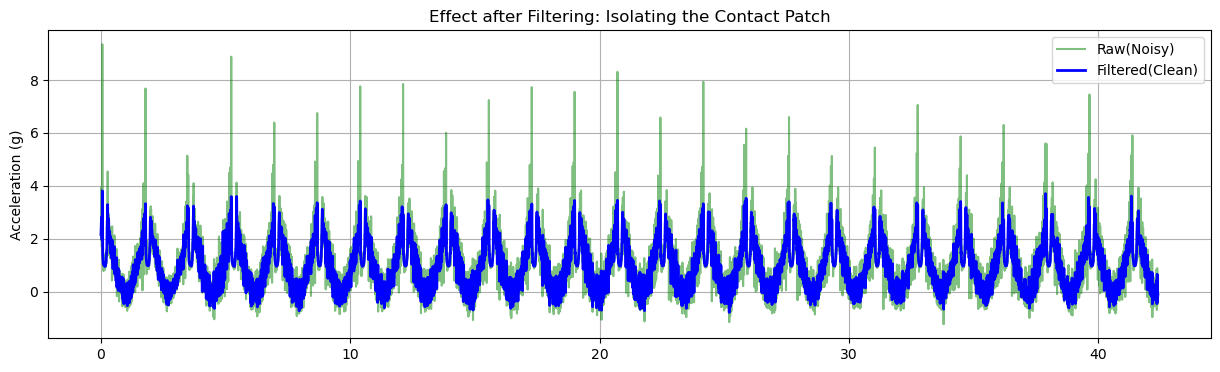

In [183]:
plt.figure(figsize=(15, 4))
plt.plot(df['time'], df['az'], label='Raw(Noisy)', color='green', alpha=0.5)
plt.plot(df['time'], df['az_filt'], label='Filtered(Clean)', color='blue', linewidth=2)
plt.title("Effect after Filtering: Isolating the Contact Patch")
plt.ylabel("Acceleration (g)")
plt.legend()
plt.grid(True)
plt.show()

Note : To detect when the sensor "falls into a hole or the point" (the contact patch), we first need to know where the "ground level" actualy. Doing these calculations to get them. After that got 0.5 as the safe margin and defined the Threshold. Finaly got the exact small times when the sensor enters and leaves the road point.

1. Define Baseline

In [184]:
baseline = df['az_filt'].quantile(0.9)
print(f"Baseline Centrifugal Force: {baseline:.2f} g")

Baseline Centrifugal Force: 2.14 g


2. Define Threshold

In [185]:
threshold = baseline * 0.5

3. Find Indices

In [186]:
in_contact = df['az_filt'] < threshold

In [187]:
transitions = in_contact.astype(int).diff()
starts = np.where(transitions == 1)[0]
ends = np.where(transitions == -1)[0]

In [188]:
if len(ends) > len(starts):
    ends = ends[1:]
elif len(starts) > len(ends):
    starts = starts[:-1]

print(f"Detected {len(starts)} complete contact patches from this given DATA.")

Detected 397 complete contact patches from this given DATA.


final Calculations

From Detected 397 complete contact patches we Calculate Duration (Delta t) & Filter out noise. A real contact patch at 10km/h should be significant.
If it's too short (< 0.05s), it's likely just a bump. Used "continue" to Skip fake ones. Finaly used a core equation in physics, Angle = Speed*Time.

In [189]:
results = []

for t_start_idx, t_end_idx in zip(starts, ends):
    duration_sec = (t_end_idx - t_start_idx) * dt
    if duration_sec < 0.05:
        continue
    omega_deg_s = df['gx'].iloc[t_start_idx:t_end_idx].mean()
    alpha_deg = abs(omega_deg_s * duration_sec)
    
results.append(alpha_deg)

Get the Output of the Final Result

In [190]:
final_alpha = np.mean(results)

print(f" Calculated Alphas for each rotation: {[round(x, 2) for x in results]}")
print(f"\n============================================================================================")
print(f" FINAL AVERAGE FOOTPRINT ANGLE (ALPHA): {final_alpha:.2f} degrees")
print(f"============================================================================================")

 Calculated Alphas for each rotation: [15.3]

 FINAL AVERAGE FOOTPRINT ANGLE (ALPHA): 15.30 degrees
